#### Sunwoo Lee
#### 7th April 2026

# Assignment 4: Emotion Image Clustering Using t-SNE, PCA, and Feature Selection 

## Imports

In [292]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as se
import cv2
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn import feature_selection, metrics
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import VarianceThreshold

In [4]:
# DATA_PATH="JAFFE_sample_dataset"
final_table_results = []

## Reused Functions

In [274]:
def calc_kmeans(data, K):
    kmean = KMeans(n_clusters=K)
    return kmean.fit_predict(data)

def calc_gmm(data, K):
    gmm = GaussianMixture(n_components=K)
    return gmm.fit_predict(data)

def calc_agg(data, K):
    agg = AgglomerativeClustering(n_clusters=K)
    return agg.fit_predict(data)

def graph_clusters(kmean_label, gmm_label, agg_label, reduction_method=''):
    plt.figure(figsize=(10, 8))

    # plotting K-means
    plt.subplot(2, 2, 1)
    plt.scatter(D_tsne[:,0], D_tsne[:,1], c=kmean_label, cmap="rainbow")
    plt.colorbar()
    plt.grid()
    plt.title(f"K-Means{f" + {reduction_method}" if reduction_method else ''}")

    # plotting Gaussian Mixture
    plt.subplot(2, 2, 2)
    plt.scatter(D_tsne[:,0], D_tsne[:,1], c=gmm_label, cmap="rainbow")
    plt.colorbar()
    plt.grid()
    plt.title(f"Gaussian Mixture{f" + {reduction_method}" if reduction_method else ''}")

    # plotting Agglomerative Clustering
    plt.subplot(2, 2, 3)
    plt.scatter(D_tsne[:,0], D_tsne[:,1], c=agg_label, cmap="rainbow")
    plt.colorbar()
    plt.grid()
    plt.title(f"Agglomerative Clustering{f" + {reduction_method}" if reduction_method else ''}")
    
    plt.tight_layout()
    plt.show()

def cluster_results(method_name, method_label, data, size, reduction_method=''):
    print(f" {method_name}{f" + {reduction_method}" if reduction_method else ''}")
    sh_score = silhouette_score(data, method_label)
    db_score = davies_bouldin_score(data, method_label)
    ari_score = adjusted_rand_score(labels, method_label)
    nmi_score = normalized_mutual_info_score(labels, method_label)
    
    print(f"  Silhouette: {sh_score}")
    print(f"  Davies Bouldin: {db_score}")
    print(f"  ARI: {ari_score}")
    print(f"  NMI: {nmi_score}\n")

    final_table_results.append({
        "Data Representation": reduction_method if reduction_method else "Original D",
        "Clustering Method": method_name,
        "Number of Features": size,
        "Silhouette": sh_score,
        "Davies-Bouldin": db_score,
        "ARI": ari_score,
        "NMI": nmi_score
    })

## Part 1: Read the Images and Create the Data Matrix D

### Tasks

In [106]:
D = []
labels = []
# 📝 Read all image files from the dataset folder.
for file_name in os.listdir(DATA_PATH):
    file_path = os.path.join(DATA_PATH, file_name)
    
    # 📝 Read each image as a grayscale image.
    image = cv2.imread(file_path,cv2.IMREAD_GRAYSCALE)
    image2 = cv2.resize(image, (64, 64))
    
    # 📝 Flatten each image into a one-dimensional feature vector.
    x = image2.flatten()
    
    # 📝 Stack all feature vectors into a data matrix D of size n x d.
    D.append(x)

    # 📝 Extract the label of each image from the filename or metadata.
    label = file_name.split(".")[1]
    labels.append(label[:2])

D = np.array(D)
labels = np.array(labels)

# 📝 Create a pandas DataFrame from D.
df = pd.DataFrame(D)

# 📝 Determine the number of unique emotion classes. Denote this number by K.
z = np.unique(labels)
K = len(z)

### Deliverables

In [176]:
print(f"✅ Shape of D: {D.shape}")
print(f"✅ Number of Samples n: {D.shape[0]}")
print(f"✅ Number of Dimensions d: {D.shape[1]}")
print("✅ first 5 rows of the DataFrame:")
print(df.head())
print(f"✅ Number of Unique Emotion Classes: {K}")

✅ Shape of D: (213, 4096)
✅ Number of Samples n: 213
✅ Number of Dimensions d: 4096
✅ first 5 rows of the DataFrame:
   0     1     2     3     4     5     6     7     8     9     ...  4086  \
0   109   114   118   117   122   123   119   120   128   133  ...   157   
1   110   112   117   122   126   129   132   138   146   145  ...   156   
2   104   104   105   109   111   112   116   122   127   131  ...   140   
3   111   108   109   113   119   121   129   133   134   133  ...   138   
4   118   115   118   123   124   125   129   132   134   136  ...   129   

   4087  4088  4089  4090  4091  4092  4093  4094  4095  
0   144   137   132   119    95   102   109   120   123  
1   148   139   127   115    95    93   103   106   110  
2   127   109    93    97   106   119   124   122   121  
3   127   110    93    96   105   119   130   136   132  
4   110    99   106   116   125   133   137   131   129  

[5 rows x 4096 columns]
✅ Number of Unique Emotion Classes: 7


## Part 2: Data Preprocessing

### Tasks

In [222]:
# 📝 Verify that all images have the same size.
img_shapes = [cv2.imread(os.path.join(DATA_PATH, f), cv2.IMREAD_GRAYSCALE).shape for f in os.listdir(DATA_PATH)]
unique_shapes = set(img_shapes)

# 📝 Verify that all rows in D have the same number of dimensions.
dim_lengths = [len(row) for row in D]
unique_lengths = set(dim_lengths)

# 📝 Check whether there are missing values in the DataFrame.
missing_values = df.isnull().sum().sum()

# 📝 Standardize the data using z-score normalization.
D_scaled = StandardScaler().fit_transform(D)
df_scaled = pd.DataFrame(D_scaled)

### Deliverables

In [174]:
print("✅ Preprocessing Summary")
print(f" Unique image shapes: {unique_shapes} ----- {"All images have the same size" if len(unique_shapes) == 1 else "Images have varying sizes"}")
print(f" Unique dimension lengths: {unique_lengths} ----- {"All rows in D have the same number of dimensions" if len(unique_lengths) == 1 else "Rows in D have varying number of dimensions"}")
print(f" Total missing values in DataFrame: {missing_values} ----- {"No missing values found" if missing_values == 0 else "There are missing values in the DataFrame"}")

print("✅ Final Processed Version of D")
print(D_scaled)

✅ Preprocessing Summary
 Unique image shapes: {(256, 256)} ----- All images have the same size
 Unique dimension lengths: {4096} ----- All rows in D have the same number of dimensions
 Total missing values in DataFrame: 0 ----- No missing values found
✅ Final Processed Version of D
[[-0.41150981 -0.36001837 -0.33240963 ... -0.64839801 -0.09103836
   0.0723524 ]
 [-0.38070081 -0.42208548 -0.36436055 ... -0.88679061 -0.67611678
  -0.4691173 ]
 [-0.56555478 -0.67035392 -0.74777166 ... -0.05241653 -0.00745573
  -0.01095063]
 ...
 [ 1.37541186  1.40889424  1.39294034 ...  1.53686744  1.53882295
   1.44685239]
 [ 0.85165896  0.88132381  0.78587276 ...  1.45740324  0.74478795
   0.94703421]
 [ 1.1905579   1.25372647  1.23318572 ...  1.81499213  1.20449242
   1.40520088]]


## Part 3: t-SNE Visualization

### Tasks

✅ 2D t-SNE Plot:


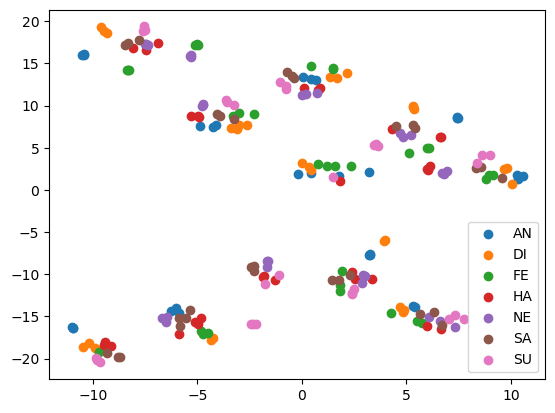

In [198]:
# 📝 Apply t-SNE to the standardized data matrix D.
# 📝 Reduce the data to 2 dimensions.
tsne = TSNE(n_components=2)
D_tsne = tsne.fit_transform(D_scaled)

# 📝 Plot the 2D t-SNE representation.
# 📝 Color the points according to the true emotion labels, if labels are available.
print("✅ 2D t-SNE Plot:")
for i in np.unique([l[:2] for l in labels]):
    idx = np.array([l[:2] for l in labels]) == i
    plt.scatter(D_tsne[idx,0], D_tsne[idx, 1], label=i)

plt.legend()
plt.show()
# 📝 Briefly discuss whether natural groups are visible.

### Deliverables

**✅ Short Interpretation**

So far, no natural grouping can be observed. Each little clusters has at least 1 of each color, denoting that the clusters might represent the different models rather than their facial emotions

## Part 4: Clustering on the Original Data

### Tasks

In [91]:
# 📝 Apply all three clustering methods to the original data.
# 📝 Use the same number of clusters K for all three methods.
# 📝 1. K-means
labels_kmeans = calc_kmeans(D_scaled, K)

# 📝 2. Gaussian Mixture Model (Expectation Maximization)
labels_gmm = calc_gmm(D_scaled, K)

# 📝 3. Agglomerative Clustering
labels_agg = calc_agg(D_scaled, K)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


✅ t-SNE Plots Showing Cluster Assignments


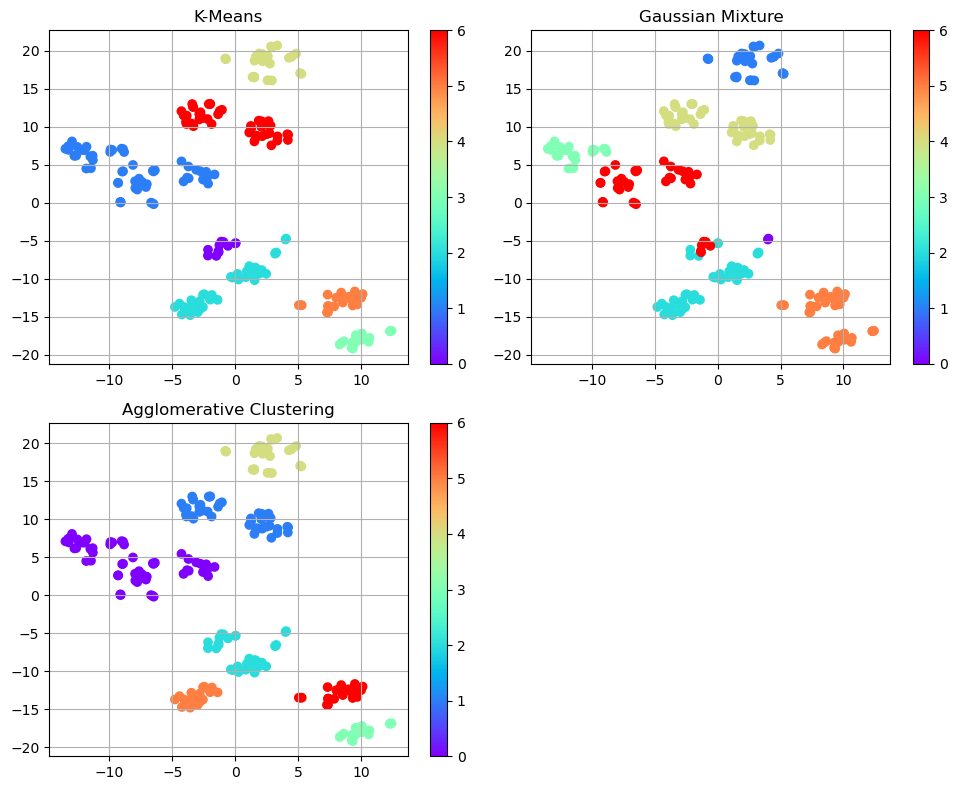

In [195]:
# 📝 Visualize the cluster assignments using the t-SNE plot.
print("✅ t-SNE Plots Showing Cluster Assignments")
graph_clusters(labels_kmeans, labels_gmm, labels_agg)

# 📝 Compare the results of the three clustering techniques.

### Deliverables

In [276]:
print("✅ Clustering Results on Original Data")
cluster_results("K-Means", labels_kmeans, D_scaled, D_scaled.shape[1])
cluster_results("Gaussian Mixture", labels_gmm, D_scaled, D_scaled.shape[1])
cluster_results("Agglomerative Clustering", labels_agg, D_scaled, D_scaled.shape[1])

✅ Clustering Results on Original Data
 K-Means
  Silhouette: 0.22609530774811162
  Davies Bouldin: 1.476194916802627
  ARI: -0.015454091466430593
  NMI: 0.032043076126195134

 Gaussian Mixture
  Silhouette: 0.23129989336484014
  Davies Bouldin: 1.524022595471768
  ARI: -0.01604218825728797
  NMI: 0.02313089436031139

 Agglomerative Clustering
  Silhouette: 0.25321247580437234
  Davies Bouldin: 1.4615437813821794
  ARI: -0.015338189998182797
  NMI: 0.021823973595719266



**✅ Comparison of the Three Methods**

Firstly, looking at the individual silhouette scores, they are all within the 0.25 range, meaning that the clustering is very poor with many cluster boundaries overlapping, which is also apparent from the Davies Bouldin scores where they are all within the 1.5 range, showing that the clusters are not very compacted. Moving on to the accuracy metrics, with them all showing negative scores for ARI, it shows that the labels are performing worse than random, meaning the clustering is not capturing the real emotion labels at all, and with NMI scores around 0.025, it shows that there is almost no coorelation between the predicted clusters and the actual emotion classes.

## Part 5: PCA and Clustering

### Tasks

✅ Explained Variance Plot
✅ Cumulative Explained Variance Plot


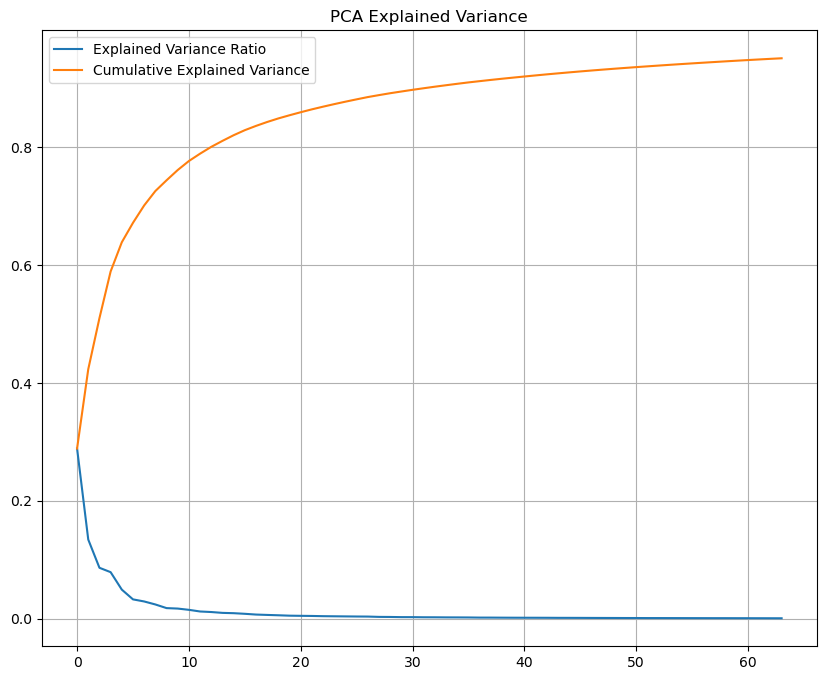

In [211]:
# 📝 Apply PCA to the standardized matrix D.
# 📝 Select the number of principal components that preserve at least 90% or 95% of the variance.
pca = PCA(n_components=0.95)
pca.fit(D_scaled)

# 📝 Construct the PCA-reduced dataset.
D_reduced = pca.transform(D_scaled)

# 📝 Plot
print("✅ Explained Variance Plot")
print("✅ Cumulative Explained Variance Plot")
plt.figure(figsize=(10, 8))

# 📝 explained variance ratio
explained_var = pca.explained_variance_ratio_
plt.plot(explained_var, label="Explained Variance Ratio")

# 📝 cumulative explained variance
cumulative_var = np.cumsum(explained_var)
plt.plot(cumulative_var, label="Cumulative Explained Variance")

plt.title("PCA Explained Variance")
plt.legend()
plt.grid()
plt.show()

In [124]:
# 📝 Use the same number of clusters K. Apply:
# 📝 1. K-means
labels_pca_kmeans = calc_kmeans(D_reduced, K)

# 📝 2. Gaussian Mixture Model
labels_pca_gmm = calc_gmm(D_reduced, K)

# 📝 3. Agglomerative Clustering
labels_pca_agg = calc_agg(D_reduced, K)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Deliverables

✅ Selected Number of Principal Components that Preserved at Least 95% Variance: 64
✅ Clustering Results After PCA


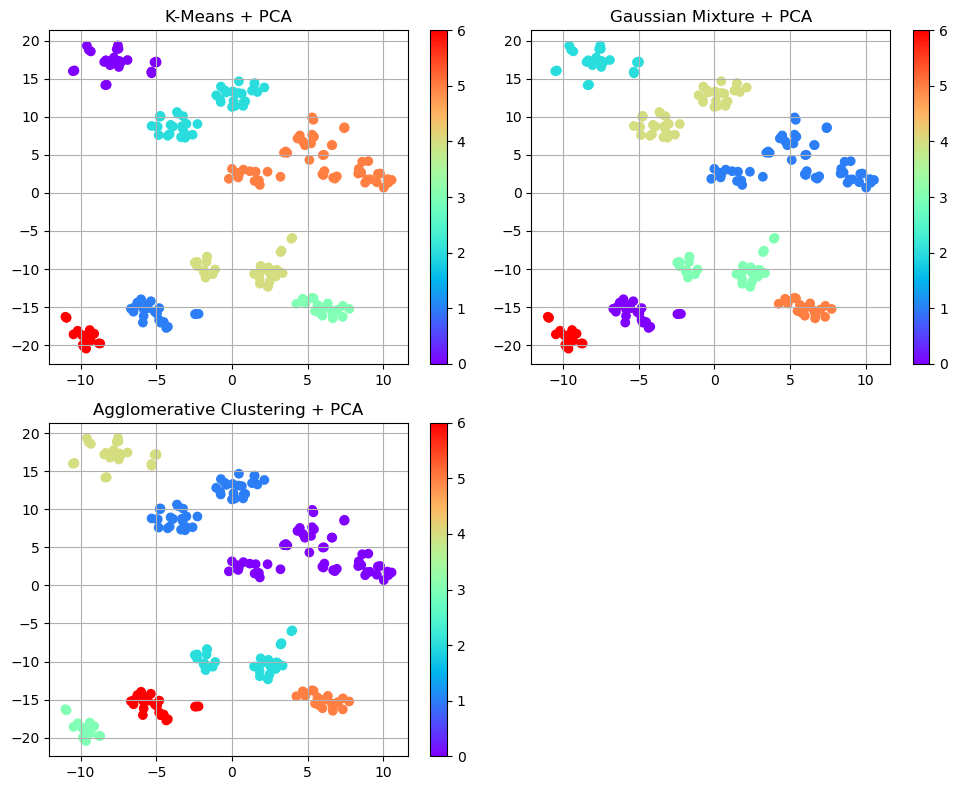

 K-Means + PCA
  Silhouette: 0.2832696821605579
  Davies Bouldin: 1.364572714694866
  ARI: -0.015338189998182797
  NMI: 0.021823973595719266

 Gaussian Mixture + PCA
  Silhouette: 0.2832696821605579
  Davies Bouldin: 1.364572714694866
  ARI: -0.015338189998182797
  NMI: 0.021823973595719266

 Agglomerative Clustering + PCA
  Silhouette: 0.2832696821605579
  Davies Bouldin: 1.364572714694866
  ARI: -0.015338189998182797
  NMI: 0.021823973595719266



In [279]:
print(f"✅ Selected Number of Principal Components that Preserved at Least 95% Variance: {D_reduced.shape[1]}")
print("✅ Clustering Results After PCA")
graph_clusters(labels_pca_kmeans, labels_pca_gmm, labels_pca_agg, reduction_method="PCA")

cluster_results("K-Means", labels_pca_kmeans, D_reduced, D_reduced.shape[1], reduction_method="PCA")
cluster_results("Gaussian Mixture", labels_pca_gmm, D_reduced, D_reduced.shape[1], reduction_method="PCA")
cluster_results("Agglomerative Clustering", labels_pca_agg, D_reduced, D_reduced.shape[1], reduction_method="PCA")

**✅ Comparison with Original Data**

After applying PCA, clustering performance improved with higher Silhouette scores and lower Davies-Bouldin indices. Interestingly, all three clustering algorithms converged to identical clustering structures, suggesting a dominant grouping pattern in the reduced feature space. However, ARI and NMI remained near zero, indicating that these clusters do not correspond to the true emotion labels. This highlights a key limitation of unsupervised methods, which is that the most natural structure in the data does not necessarily align with the intended classification task.

## Part 6-8: Feature Selection and Clustering

### L1-Based Feature Selection Tasks

In [62]:
# 📝 Apply an L1-based model to select important features.
lr = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.5,
    max_iter=5000
)
lr.fit(D_scaled, labels)

# 📝 Keep features whose coefficients are nonzero or sufficiently important.
lr_coefs = lr.coef_
lr_max_coef = np.max(np.abs(lr_coefs), axis=0)
threshold = 1e-5
lr_selected_features = lr_max_coef > threshold

# 📝 Construct a reduced dataset using the selected features.
D_lr_reduced = D_scaled[:, lr_selected_features]

In [151]:
# 📝 Apply:
# 📝 K-means
labels_lr_kmeans = calc_kmeans(D_lr_reduced, K)

# 📝 Gaussian Mixture Model
labels_lr_gmm = calc_gmm(D_lr_reduced, K)

# 📝 Agglomerative Clustering
labels_lr_agg = calc_agg(D_lr_reduced, K)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


✅ Number of Selected Features: 758
✅ C0lustering Results After L1-Based Feature Selection


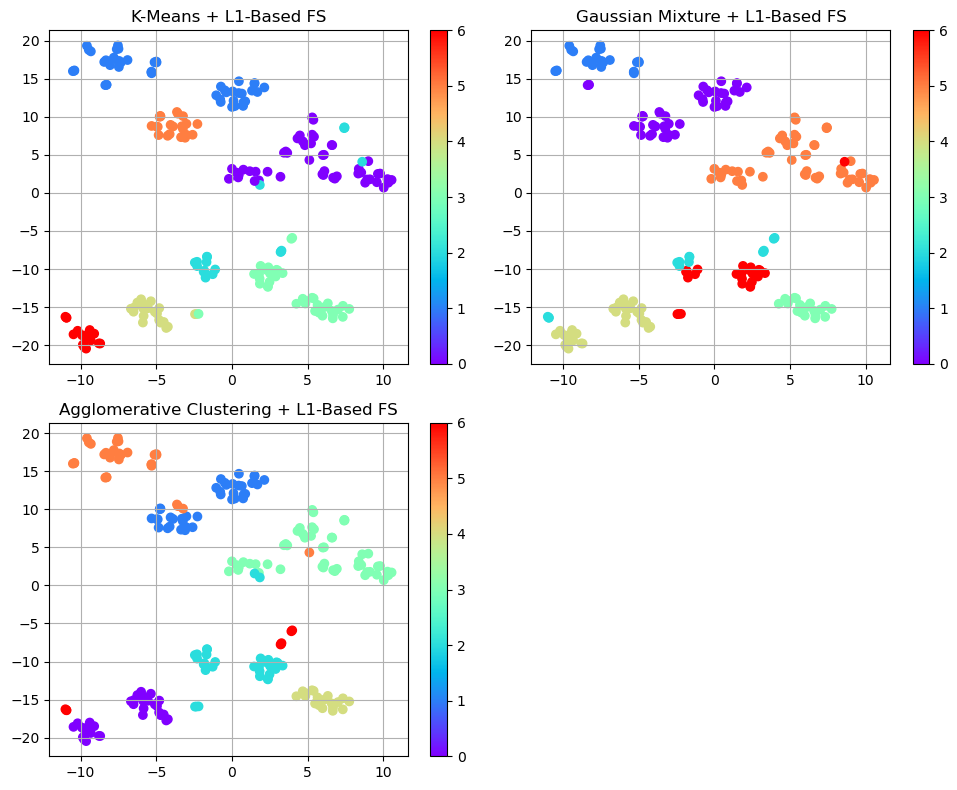

 K-Means + L1-Based FS
  Silhouette: 0.14188324485222684
  Davies Bouldin: 2.1191965603392138
  ARI: -0.011347222292727674
  NMI: 0.036913312010065424

 Gaussian Mixture + L1-Based FS
  Silhouette: 0.14737687335364935
  Davies Bouldin: 2.045594903577944
  ARI: -0.0005592219234693211
  NMI: 0.06187375991971028

 Agglomerative Clustering + L1-Based FS
  Silhouette: 0.14797436935993663
  Davies Bouldin: 1.9852407175193432
  ARI: 0.0036399774232228933
  NMI: 0.07394244343856295



In [281]:
print(f"✅ Number of Selected Features: {D_lr_reduced.shape[1]}")

print("✅ C0lustering Results After L1-Based Feature Selection")

graph_clusters(labels_lr_kmeans, labels_lr_gmm, labels_lr_agg, "L1-Based FS")

cluster_results("K-Means", labels_lr_kmeans, D_lr_reduced, D_lr_reduced.shape[1], reduction_method="L1-Based FS")
cluster_results("Gaussian Mixture", labels_lr_gmm, D_lr_reduced, D_lr_reduced.shape[1], reduction_method="L1-Based FS")
cluster_results("Agglomerative Clustering", labels_lr_agg, D_lr_reduced, D_lr_reduced.shape[1], reduction_method="L1-Based FS")

**✅ Comparison With Original Data and PCA**

L1-based feature selection led to a decrease in clustering quality, as shown by lower Silhouette scores and higher Davies-Bouldin indices. However, it improved ARI and NMI, indicating better alignment with the true emotion labels. This suggests that L1 feature selection retains label-relevant features at the cost of overall cluster compactness. This leads to the previous observation that the most natural structure in the data does not necessarily align with the intended classification task

### Correlation-Based Feature Selection Tasks

In [246]:
# 📝 Compute the correlation matrix of the features.
corr_matrix = df_scaled.corr().abs()

# 📝 Remove highly correlated features using a threshold such as:
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# 📝 0.85
drop_85 = [col for col in upper.columns if any(upper[col] > 0.85)]

In [348]:
# 📝 Construct the reduced dataset.
df_85 = df.drop(columns=drop_85)

In [248]:
# 📝 Apply:
# 📝 K-means
labels_85_kmeans = calc_kmeans(df_85, K)

# 📝 Gaussian Mixture Model
labels_85_gmm = calc_gmm(df_85, K)

# 📝 Agglomerative Clustering
labels_85_agg = calc_agg(df_85, K)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### Deliverables

✅ Chosen Correlation Threshold: 0.85
✅ Number of Remaining Features: 348
✅ Clustering Results After Correlation-Based Feature Selection


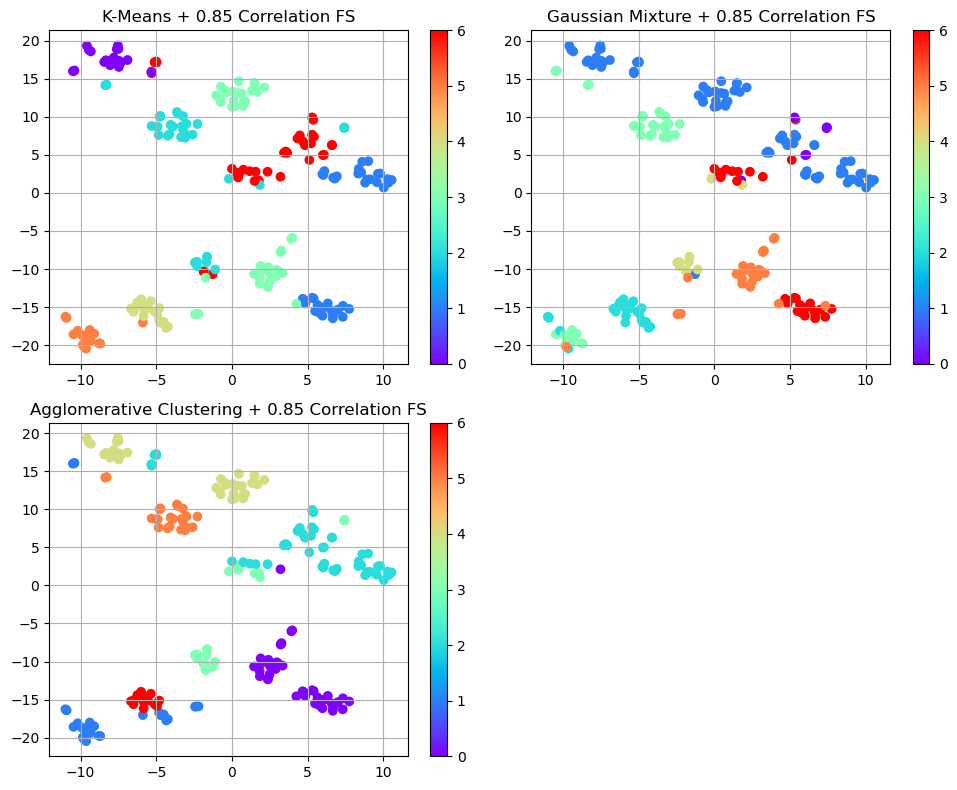

 K-Means + 0.85 Correlation FS
  Silhouette: 0.11407369897913545
  Davies Bouldin: 2.3734026097059453
  ARI: -0.011157687360130895
  NMI: 0.03622839441592049

 Gaussian Mixture + 0.85 Correlation FS
  Silhouette: 0.11882414247434361
  Davies Bouldin: 2.1425133347403293
  ARI: 0.002348017806965523
  NMI: 0.06120187563033146

 Agglomerative Clustering + 0.85 Correlation FS
  Silhouette: 0.11237812203743015
  Davies Bouldin: 2.2340744611553975
  ARI: -0.0015076515450421495
  NMI: 0.05745907960780119



In [283]:
print("✅ Chosen Correlation Threshold: 0.85")
print("✅ Number of Remaining Features:", df_85.shape[1])
print("✅ Clustering Results After Correlation-Based Feature Selection")
graph_clusters(labels_85_kmeans, labels_85_gmm, labels_85_agg, reduction_method="0.85 Correlation FS")

cluster_results("K-Means", labels_85_kmeans, df_85, df_85.shape[1], reduction_method="0.85 Correlation FS")
cluster_results("Gaussian Mixture", labels_85_gmm, df_85, df_85.shape[1], reduction_method="0.85 Correlation FS")
cluster_results("Agglomerative Clustering", labels_85_agg, df_85, df_85.shape[1], reduction_method="0.85 Correlation FS")

**✅ Comparison with Previous Results**

Compared to the original dataset, it improved both clustering metrics (Silhouette, Davies-Bouldin) and ARI and NMI scores, indicating better-defined and more meaningful clusters. While PCA provided competitive silhouette scores, it did not consistently improve alignment with true labels, likely due to loss of interpretability and class-discriminative information. L1-based feature selection performed slightly better, with higher ARI and NMI scores, suggesting that overall cluster structure does not reflect the class correlation. Finally, correlation filtering at 0.85 offered the best balance between dimensionality reduction and clustering performance.

## Variance Threshold Tasks

In [340]:
variances = np.var(D, axis=0)
print("Min variance:", np.min(variances))
print("Max variance:", np.max(variances))
print("Mean variance:", np.mean(variances))

Min variance: 5.198703960854331
Max variance: 6926.69443893407
Mean variance: 1527.770317091258


In [346]:
# 📝 Remove features with very low variance.
selector = VarianceThreshold(threshold=1000)

# 📝 Construct the reduced dataset.
D_var_reduced = selector.fit_transform(D)

In [350]:
# 📝 Apply:
# 📝 K-means
labels_var_kmeans = calc_kmeans(D_var_reduced, K)

# 📝 Gaussian Mixture Model
labels_var_gmm = calc_gmm(D_var_reduced, K)

# 📝 Agglomerative Clustering
labels_var_agg = calc_agg(D_var_reduced, K)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## Deliverables

✅ Variance Threshold Used: 1000
✅ Number of Remaining Features 2287
✅ Clustering Results After Variance-Threshold Feature Selection


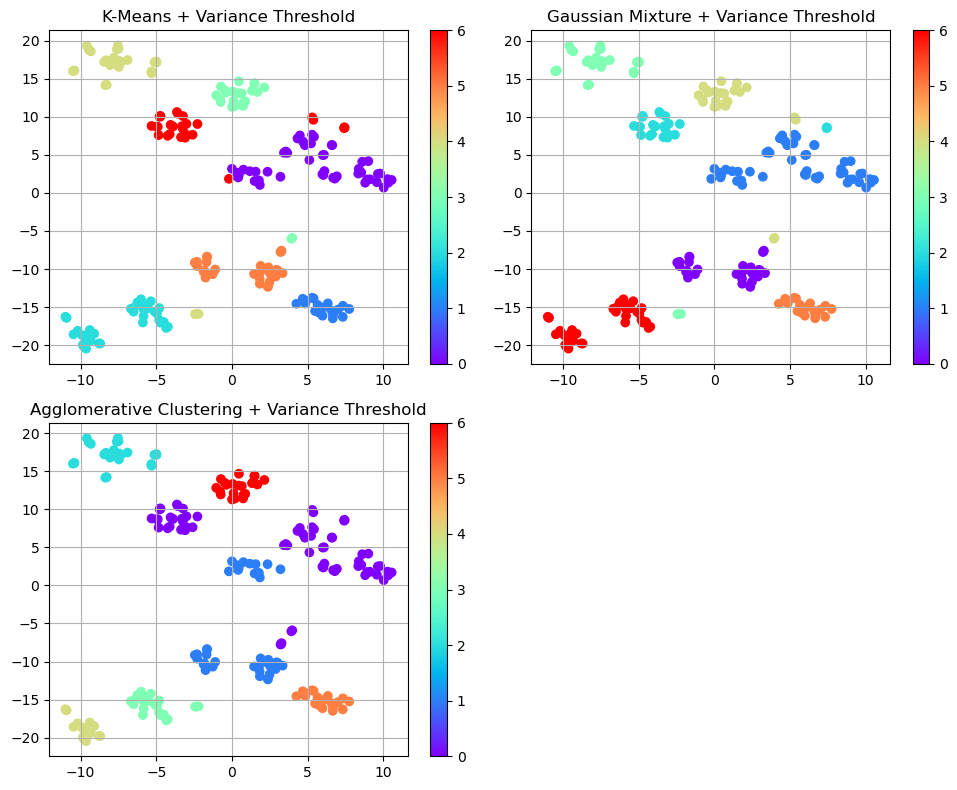

 K-Means + Variance Threshold
  Silhouette: 0.21116220164138513
  Davies Bouldin: 1.7066184711966048
  ARI: -0.00914991200032225
  NMI: 0.032412251191435724

 Gaussian Mixture + Variance Threshold
  Silhouette: 0.20721942665409732
  Davies Bouldin: 1.672571222256222
  ARI: -0.008756526106109682
  NMI: 0.03295087474632263

 Agglomerative Clustering + Variance Threshold
  Silhouette: 0.21614651428289555
  Davies Bouldin: 1.6748482484446507
  ARI: -0.01573854489042982
  NMI: 0.018528272936417414



In [354]:
print("✅ Variance Threshold Used: 1000")
print("✅ Number of Remaining Features", D_var_reduced.shape[1])
print("✅ Clustering Results After Variance-Threshold Feature Selection")
graph_clusters(labels_var_kmeans, labels_var_gmm, labels_var_agg, reduction_method="Variance Threshold")

cluster_results("K-Means", labels_var_kmeans, D_var_reduced, D_var_reduced.shape[1], reduction_method="Variance Threshold")
cluster_results("Gaussian Mixture", labels_var_gmm, D_var_reduced, D_var_reduced.shape[1], reduction_method="Variance Threshold")
cluster_results("Agglomerative Clustering", labels_var_agg, D_var_reduced, D_var_reduced.shape[1], reduction_method="Variance Threshold")

**✅ Comparison With Previous Results**

Variance Threshold produced results nearly identical to the original dataset, as it removed only a small number of features. This highlights its limitation on image data, where most pixels exhibit sufficient variance and meaningful structure lies in feature relationships rather than magnitude.

## Final Comparison Table

In [360]:
final_comparison_df = pd.DataFrame(final_table_results)
final_comparison_df = final_comparison_df.drop_duplicates()
final_comparison_df

,Data Representation,Clustering Method,Number of Features,Silhouette,Davies-Bouldin,ARI,NMI
0,Original D,K-Means,4096,0.226095,1.476195,-0.015454,0.032043
1,Original D,Gaussian Mixture,4096,0.231300,1.524023,-0.016042,0.023131
2,Original D,Agglomerative Clustering,4096,0.253212,1.461544,-0.015338,0.021824
3,PCA,K-Means,64,0.283270,1.364573,-0.015338,0.021824
4,PCA,Gaussian Mixture,64,0.283270,1.364573,-0.015338,0.021824
5,PCA,Agglomerative Clustering,64,0.283270,1.364573,-0.015338,0.021824
6,L1-Based FS,K-Means,758,0.141883,2.119197,-0.011347,0.036913
7,L1-Based FS,Gaussian Mixture,758,0.147377,2.045595,-0.000559,0.061874
8,L1-Based FS,Agglomerative Clustering,758,0.147974,1.985241,0.003640,0.073942
9,0.85 Correlation FS,K-Means,348,0.114074,2.373403,-0.011158,0.036228


## Questions to Answer

1. Did t-SNE reveal visible group structure in the data?

    t-SNE showed weak and overlapping group structure. While some small clusters appeared, the classes were not clearly separable, indicating that the raw pizel-based features do not naturally form distinct groups in lower-dimensional space.

2. Which clustering method worked best on the original data?

    On the original data, Agglomerative clustering generally performed best compared to K-Means and Gaussian Misture. It achieved the highest silhouette score of 0.253 and the lowest Davies-Bouldin index of 1.462 among the three methods. However, overall performance was still modest, suggesting limited separability.

3. Did PCA improve clustering quality?

    Yes, PCA clearly improved clustering quality. All clustering methods on PCA-transformed data achieved the highest silhouette score of 0.283 and the lowest Davies_Bouldin index of 1.365 in the entire table, showing better defined clusters after dimensionality reduction.

4. Which feature-selection method produced the best result?

    In terms of clustering, Variance Threshold performed the best among the feature selection methods, as it obtained the highest silhouette score of 0.216 and the lowest Davies-Bouldin index of 1.672 compared to L1 and correlation based methods. On the other hand, in terms of label accuracy, L1-Based performed the best, obtaining the highest ARI score of 0.0036 and the highest NMI score of 0.0739 in the entire table.

5. Did reducing the number of features improve or hurt clustering?

    Reducing features had mixed effects, as it improved performance when using PCA, going from 4096 to 64 features, which enhanced cluster quality, whereas it hurt performance when using L1 or correlation-based feature selection, likely due to removing informative features. This suggests that the way in which features are reduced matters more than the amount thats removed.

6. Which representation gave the best overall clustering performance?

    Like mentioned before, PCA, with its 64 features, gave the best overall clustering performance. It consistantly produced the highest silhouette scores and the lowest Davies-Bouldin indices, indicating the most well structured cluster across all methods.

7. What are the limitations of clustering grayscale facial-expression images using pixel features?

    The results highlight several limitations. Low ARI and NMI scores across all methods show poor alignment with true emotion labels, which could indicate that the expressions are too subtle and overlapping, making clusters hard to separate. Also, because the images were gray scaled, the pixels were sensitive to lighting and alignment, and the variation future reduced clustering qualities. These limitations explain why even the best setup, PCA, still produced relatively weak clustering performance.